## LR

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import numpy as np

lr = 5e-3
weight_decay = 1e-2

epoch_fraction = 0.2
samples_per_epoch = int(epoch_fraction * (3 * 124_000))

warmup_pct = 0.1
steps_per_epoch = (samples_per_epoch + 32 - 1) // 32  # Ceiling division

total_steps = 50 * steps_per_epoch
warmup_steps = int(warmup_pct * total_steps)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        # Linear warm-up
        return float(current_step) / float(max(1, warmup_steps))
    else:
        # Cosine annealing after warm-up
        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        lr = 0.5 * (1.0 + np.cos(np.pi * progress))
        return max(lr, 1e-6) # Ensure nonzero

In [3]:
steps_per_epoch

2325

Text(0.5, 1.0, 'Learning Rate Schedule')

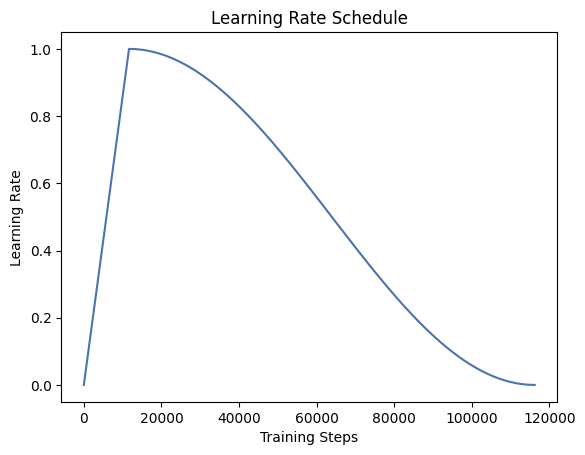

In [4]:
sns.set_palette("deep")
lr_schedule = [lr_lambda(i) for i in range(total_steps)]
sns.lineplot(x=range(total_steps), y=lr_schedule)
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")

## Viz

In [5]:
import torch
from models.Week7EGNN import JetFlowMatcher


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
colors = sns.color_palette("deep", n_colors=5)

In [6]:
path = "downloaded_output/2025-08-13_20-00-09--b22800bf-2d45-4562-b1c5-e3b70a05b018"
initial_model_info = torch.load(f"{path}/train/models/initial_model.pth", map_location=device, weights_only=False)
final_model_info = torch.load(f"{path}/train/models/final_model.pth", map_location=device, weights_only=False)
final_model_info

OrderedDict([('time_embedding.fc1.weight',
              tensor([[-0.0946,  0.0279, -0.0309,  ..., -0.0673, -0.0088, -0.0290],
                      [-0.0573,  0.0369,  0.0136,  ...,  0.0660,  0.0005, -0.0788],
                      [ 0.0063, -0.0401,  0.0154,  ..., -0.0031,  0.1761, -0.0526],
                      ...,
                      [-0.0241,  0.0325, -0.0634,  ..., -0.0195, -0.0602, -0.0037],
                      [ 0.0586, -0.0270, -0.0365,  ...,  0.0111, -0.0114, -0.0493],
                      [-0.0458, -0.0005, -0.0434,  ...,  0.0181,  0.0568,  0.0461]])),
             ('time_embedding.fc1.bias',
              tensor([-0.0173,  0.0544,  0.0230, -0.2163, -0.0480, -0.4757, -0.0581,  0.0184,
                       0.0245, -0.0292,  0.3045,  0.0064, -0.0537, -0.0572, -0.0307, -0.0515,
                       0.0364,  1.1103,  0.0666,  0.0283, -0.0078,  0.0228,  0.0462,  0.0632,
                      -0.0208, -0.0055,  0.0440, -0.0020, -0.0103, -0.0037,  0.0109, -0.0092])),
   

In [7]:
final_model = JetFlowMatcher(
    max_num_jet_types=5, 
    num_layers=5,
    hidden_dim=128,
    use_residual_update=True
)
initial_model = JetFlowMatcher(
    max_num_jet_types=5,
    num_layers=5,
    hidden_dim=128,
    use_residual_update=True
)
initial_model.load_state_dict(initial_model_info)
final_model.load_state_dict(final_model_info)

<All keys matched successfully>

In [8]:
import pickle
from util.coordinates import transform_rel_particle_coordinates_to_cartesian

with open(f"{path}/data/x_test.pkl", "rb") as f:
    X_test = pickle.load(f)
X_test

/Users/arjunsharma/development/s25-fermilab-research/src/venv/lib/python3.10/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


Dataset JetNet
    Number of datapoints: 53176
    Data location: datasets/jetnet
    Including ['g'] jets
    Split into valid data out of ['train', 'valid', 'test', 'all'] possible splits, with splitting fractions [0.7, 0.30000000000000004, 0]
    Particle features: ['etarel', 'phirel', 'ptrel', 'mask'], max 30 particles per jet
    Jet features: ['eta', 'pt', 'mass', 'num_particles', 'type']
    Jet normalisation: Shift features by 0.0 and then multiplying by 1.0

In [9]:
scale = open(f"{path}/train/scale.txt").read().strip()
scale = float(scale)
scale

48.785308837890625

In [10]:
import os
from util import jet_attributes
from util.distributions import gen_initial_distribution

from util.file_management import make_clear_folder
def generate_model_vector_field(out_dir, final_model, jet_attr_model, X_test, scale, n_jet_types, n_particles_per_jet, n_features_per_particle=4, n_viz_samples=1000, zoom_in=True, save_videos=True, clamp_stddevs=3, integration_steps=16):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    output_path = f"{out_dir}/vf_viz"
    make_clear_folder(output_path)

    X_test_particle_transformed = transform_rel_particle_coordinates_to_cartesian(X_test)
    X_test_samples = X_test_particle_transformed[:n_viz_samples]
    X_test_samples = X_test_samples / scale
    X_test_samples = X_test_samples.to(device)
    print("Got x test")

    with torch.no_grad():
        final_model.eval()
        jet_attr_model.eval()
    
        generated_jet_attrs, _ = jet_attributes.generate_jets(jet_attr_model, device, n_jet_types=n_jet_types, num_jets=n_viz_samples)
        jet_one_hot_enc = generated_jet_attrs[:, :5].to(device)
        n_gen_particles = generated_jet_attrs[:, -1].long().to(device)

        masks = jet_attributes.generate_masks(
            n_gen_particles,
            max_particles_per_jet=n_particles_per_jet,
            device=device
        )
        generated_jet_attrs = torch.cat([
            jet_one_hot_enc,
            n_gen_particles.unsqueeze(-1).float()
        ], dim=-1)
        print("generated jet attributes shape:", generated_jet_attrs.shape)

        x = gen_initial_distribution(
            current_batch_size=n_viz_samples,
            num_particles=n_particles_per_jet,
            num_particle_features=n_features_per_particle,
            clamp_stddevs=clamp_stddevs
        )
        x = x.to(device)
        x_0 = x.clone()

        x = x * masks.unsqueeze(-1).expand(-1, -1, n_features_per_particle)
        x_model_final = x.clone()

        times = torch.linspace(0, 1, integration_steps + 1).to(device)
        sns.set_palette("deep")
        for i in range(len(times) - 1):
            t = times[i].unsqueeze(0).repeat(n_viz_samples).to(device)
            # TODO
            final_field = final_model.forward(x_model_final, t, generated_jet_attrs, masks)
            # final_field = torch.randn_like(x_model_final)
            print(f"{i=}, {times[i]=}, {times[i+1]=}, {final_field.mean()=}, {final_field.std()=}")
            plt.close()
            plt.clf()
            plt.figure(figsize=(10, 10))

            final_field_flat = final_field[:, :, :2].flatten(start_dim=0, end_dim=1)
            final_field_flat = final_field_flat * (times[i+1] - times[i])

            sns.scatterplot(
                x=X_test_samples[:, :, 0].cpu().numpy().flatten(),
                y=X_test_samples[:, :, 1].cpu().numpy().flatten(),
                label="Test data",
                alpha=0.75,
                color=colors[2],
                s=0.2
            )
            plt.scatter(
                x_model_final[:, :, 0].flatten().cpu().numpy(),
                x_model_final[:, :, 1].flatten().cpu().numpy(),
                label="Current data distribution",
                alpha=0.75,
                color=colors[3],
                s=0.5
            )

            plt.quiver(
                x_model_final[:, :, 0].flatten().cpu().numpy(),
                x_model_final[:, :, 1].flatten().cpu().numpy(),
                final_field_flat[:, 0],
                final_field_flat[:, 1],
                label="Final model vector field",
                alpha=0.75,
                color=colors[0],
                angles='xy',  # interpret vector components in data coordinates
                scale_units='xy',  # scale arrows in the same units as x/y
                scale=1           # no automatic rescaling
            )

            plt.xlabel(r"$E/c$ ")
            plt.ylabel(r"$p_x$")
            plt.title(r"$t=%.2f \rightarrow t=%.2f$" % (times[i].item(), times[i+1].item()))

            plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
            plt.savefig(f"{output_path}/field_vectors_{i}.png", bbox_inches='tight', dpi=300)

            if zoom_in:
                plt.xlim(-1, 1)
                plt.ylim(-1, 1)
                plt.savefig(f"{output_path}/field_vectors_zoomed_{i}.png", bbox_inches='tight', dpi=300)
            
            x_model_final = x_model_final + (final_field * (times[i+1] - times[i]))
            print(f"{x_model_final.mean()=}, {x_model_final.std()=}")

            plt.clf()
            plt.close()
            del final_field, final_field_flat
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    # Final status
    sns.scatterplot(
        x=X_test_samples[:, :, 0].cpu().numpy().flatten(),
        y=X_test_samples[:, :, 1].cpu().numpy().flatten(),
        label="Test data",
        alpha=0.75,
        color=colors[2],
        s=0.2
    )
    plt.scatter(
        x_model_final[:, :, 0].flatten().cpu().numpy(),
        x_model_final[:, :, 1].flatten().cpu().numpy(),
        label="Current data distribution",
        alpha=0.75,
        color=colors[3],
        s=0.5
    )
    plt.xlabel(r"$E/c$ ")
    plt.ylabel(r"$p_x$")
    plt.title(r"$t=%.2f \rightarrow t=%.2f$" % (times[i].item(), times[i+1].item()))
    plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
    plt.savefig(f"{output_path}/field_vectors_{i+1}.png", bbox_inches='tight', dpi=300)
    if zoom_in:
        plt.xlim(-1, 1)
        plt.ylim(-1, 1)
        plt.savefig(f"{output_path}/field_vectors_zoomed_{i+1}.png", bbox_inches='tight', dpi=300)
    
    if save_videos:
        os.system(f"ffmpeg -r 7 -i {output_path}/field_vectors_zoomed_%01d.png -vcodec mpeg4 -y  {output_path}/movie_zoomed_in.mp4")
        os.system(f"ffmpeg -r 7 -i {output_path}/field_vectors_%01d.png -vcodec mpeg4 -y  {output_path}/movie_zoomed_out.mp4")

    fig, axs = plt.subplots(4, figsize=(10, 10))
    feature_names = [r"$E/c$", r"$p_x$", r"$p_y$", r"$p_z$"]
    for i in range(4):
        sns.histplot(
            x=X_test_samples[:, :, i].cpu().numpy().flatten(),
            ax=axs[i],
            label="Test data",
            alpha=0.75,
            color=colors[2],
            bins=100
        )
        sns.histplot(
            x=x_model_final[:, :, i].cpu().numpy().flatten(),
            ax=axs[i],
            label="Current data distribution",
            alpha=0.75,
            color=colors[3],
            bins=100
        )
        axs[i].set_title(f"{feature_names[i]}")
        axs[i].legend()

    plt.tight_layout()
    plt.savefig(f"{output_path}/feature_histograms.png", bbox_inches='tight', dpi=300)

    return x_0, x_model_final, masks

In [11]:
torch.manual_seed(42)
jet_attr_generator = jet_attributes.load_model(f"{path}/jet_attr_model.pth").to(device)

Got x test
generated jet attributes shape: torch.Size([100, 6])
Layer 0: x mean 0.0022, std 0.4352
message_scalings.mean()=tensor(-0.0003) message_scalings.std()=tensor(0.0014) message_scalings.min()=tensor(-0.0073) message_scalings.max()=tensor(-0.)
reweight_factors.mean()=tensor(-0.0080) reweight_factors.std()=tensor(2.9350e-08) reweight_factors.min()=tensor(-0.0080) reweight_factors.max()=tensor(-0.0080)
reweight_term.mean()=tensor(-1.7146e-05) reweight_term.std()=tensor(0.0035) reweight_term.min()=tensor(-0.0239) reweight_term.max()=tensor(0.0239)
displacement_term.mean()=tensor(-5.4570e-16) displacement_term.std()=tensor(5.9543e-06) displacement_term.min()=tensor(-4.9359e-05) displacement_term.max()=tensor(5.0442e-05)
Layer 1: x mean -0.0000, std 0.0035
message_scalings.mean()=tensor(1.2789e-06) message_scalings.std()=tensor(6.4852e-06) message_scalings.min()=tensor(0.) message_scalings.max()=tensor(3.4175e-05)
reweight_factors.mean()=tensor(5.6945) reweight_factors.std()=tensor(0

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 16.0.0 (clang-1600.0.26.6)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.1.1_3 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex

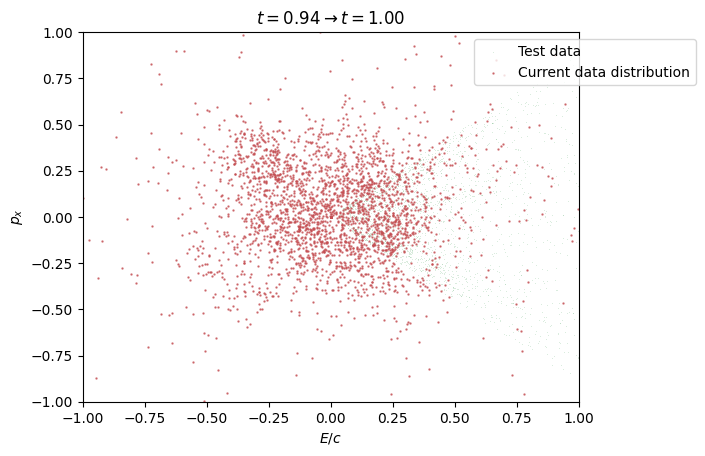

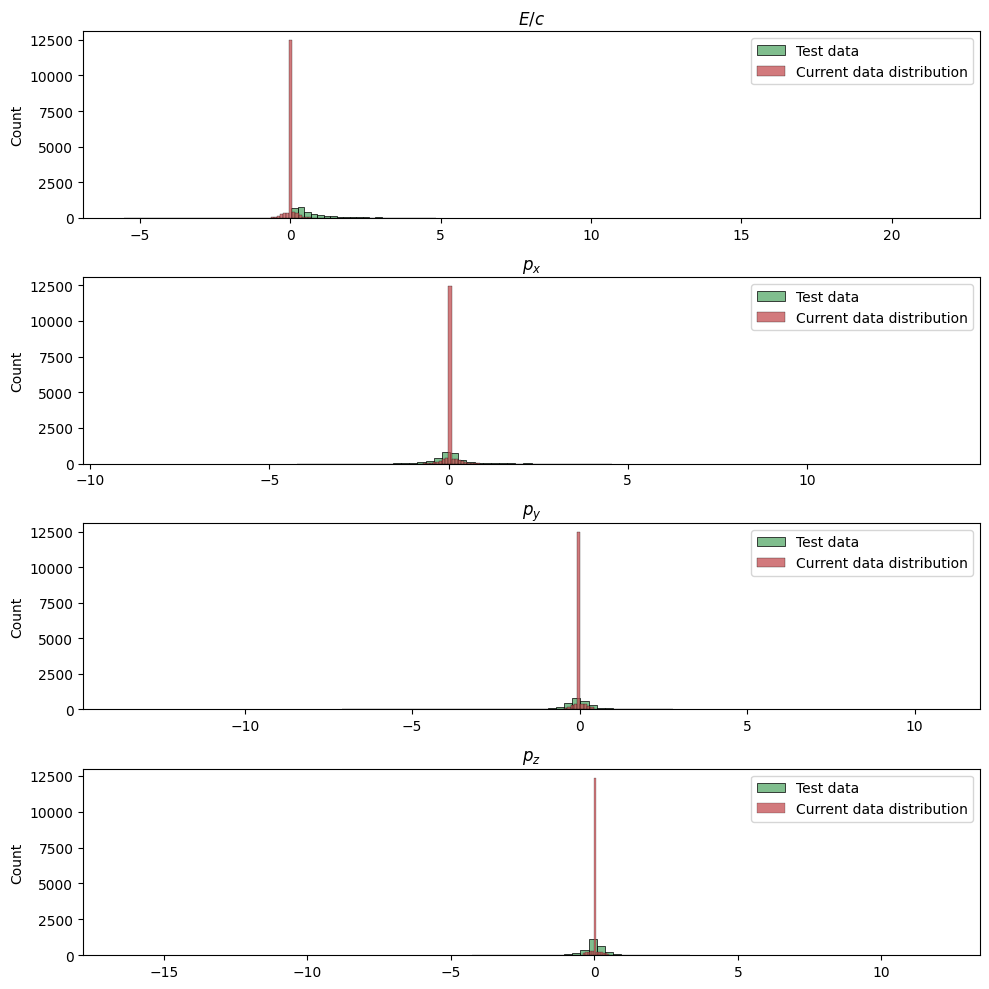

In [12]:
x_0, x_model_final, masks = generate_model_vector_field(
    out_dir=path,
    final_model=final_model,
    jet_attr_model=jet_attr_generator,
    X_test=X_test,
    scale=scale,
    n_jet_types=3,
    n_particles_per_jet=150,
    n_viz_samples=100
)

In [13]:
plt.scatter(x=x_model_final)
plt.scatter(x=x_0)

TypeError: scatter() missing 1 required positional argument: 'y'